Louvain between corona and human


In [4]:
import pandas as pd

file_path = "corona_human.csv"

df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
df.head()  # Kiểm tra 5 dòng đầu tiên

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,TREMBL Accessions Interactor B,REFSEQ Accessions Interactor B,Ontology Term IDs,Ontology Term Names,Ontology Term Categories,Ontology Term Qualifier IDs,Ontology Term Qualifier Names,Ontology Term Types,Organism Name Interactor A,Organism Name Interactor B
0,2652341,43740570,8546,4383845,114116,GU280_gp04,-,E,AP3B1,env|envelope|SARS-CoV2 E|E protein|emp|SARS-Co...,...,-,NP_001258698|NP_003655,-,-,-,-,-,-,Severe acute respiratory syndrome coronavirus 2,Homo sapiens
1,2652342,43740570,23476,4383845,117036,GU280_gp04,-,E,BRD4,env|envelope|SARS-CoV2 E|E protein|emp|SARS-Co...,...,-,NP_001317313|NP_490597|NP_001366221|NP_0013662...,-,-,-,-,-,-,Severe acute respiratory syndrome coronavirus 2,Homo sapiens
2,2652343,43740570,6046,4383845,111973,GU280_gp04,DADB-17J1.3,E,BRD2,env|envelope|SARS-CoV2 E|E protein|emp|SARS-Co...,...,X5CF57|A0A024RCR5,NP_001186384|NP_005095|NP_001278915|NP_0011066...,-,-,-,-,-,-,Severe acute respiratory syndrome coronavirus 2,Homo sapiens
3,2652344,43740570,10283,4383845,115572,GU280_gp04,UNQ438/PRO871,E,CWC27,env|envelope|SARS-CoV2 E|E protein|emp|SARS-Co...,...,D6REK3,NP_001284574|NP_005860|NP_001351407|NP_0013049...,-,-,-,-,-,-,Severe acute respiratory syndrome coronavirus 2,Homo sapiens
4,2652345,43740570,124245,4383845,125858,GU280_gp04,-,E,ZC3H18,env|envelope|SARS-CoV2 E|E protein|emp|SARS-Co...,...,B4DTK7|E7ERS3,NP_653205|NP_001281269,-,-,-,-,-,-,Severe acute respiratory syndrome coronavirus 2,Homo sapiens


In [5]:
# 🚀 2. Lọc dữ liệu chỉ giữ lại tương tác giữa virus Corona ↔ Con người
corona_id = 2697049  # Organism ID của SARS-CoV-2
human_id = 9606      # Organism ID của con người

df_filtered = df[(df["Organism ID Interactor A"] == corona_id) & (df["Organism ID Interactor B"] == human_id) |
                 (df["Organism ID Interactor A"] == human_id) & (df["Organism ID Interactor B"] == corona_id)]


In [6]:
import networkx as nx
import community  # python-louvain
import matplotlib.pyplot as plt

In [7]:
# Tạo đồ thị
G = nx.Graph()

for _, row in df_filtered.iterrows():
    protein_A = row["Official Symbol Interactor A"]
    protein_B = row["Official Symbol Interactor B"]
    G.add_edge(protein_A, protein_B)


# Thông tin về đồ thị
print(f"Số nút (protein): {G.number_of_nodes()}")
print(f"Số cạnh (mối quan hệ tương tác): {G.number_of_edges()}")

Số nút (protein): 7404
Số cạnh (mối quan hệ tương tác): 30102


In [8]:
# 🚀 4. Áp dụng thuật toán Louvain để tìm cộng đồng
partition = community.best_partition(G)  # Dictionary: {node: community_id}


Vẽ biểu đồ cho tất cả cộng đồng của tập dữ liệu tương tác protein tương tác giữa người và virus

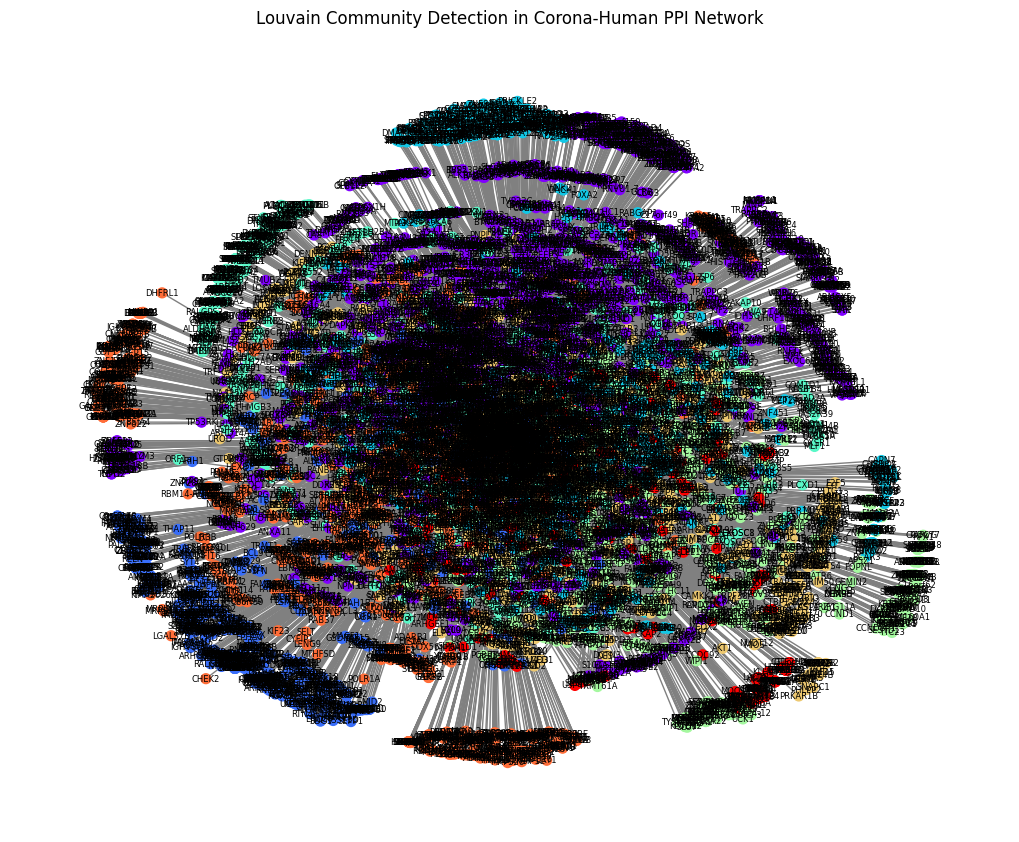

In [9]:
# 🚀 5. Vẽ mạng lưới + phân cộng đồng bằng màu sắc
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)  # Định vị các node

# Tô màu các node theo cộng đồng
colors = [partition[n] for n in G.nodes()]
nx.draw(G, pos, node_color=colors, cmap=plt.cm.rainbow, with_labels=True, node_size=50, font_size=6, edge_color="gray")

plt.title("Louvain Community Detection in Corona-Human PPI Network")
plt.show()

Vẽ biểu đồ cho top 5 cộng đồng

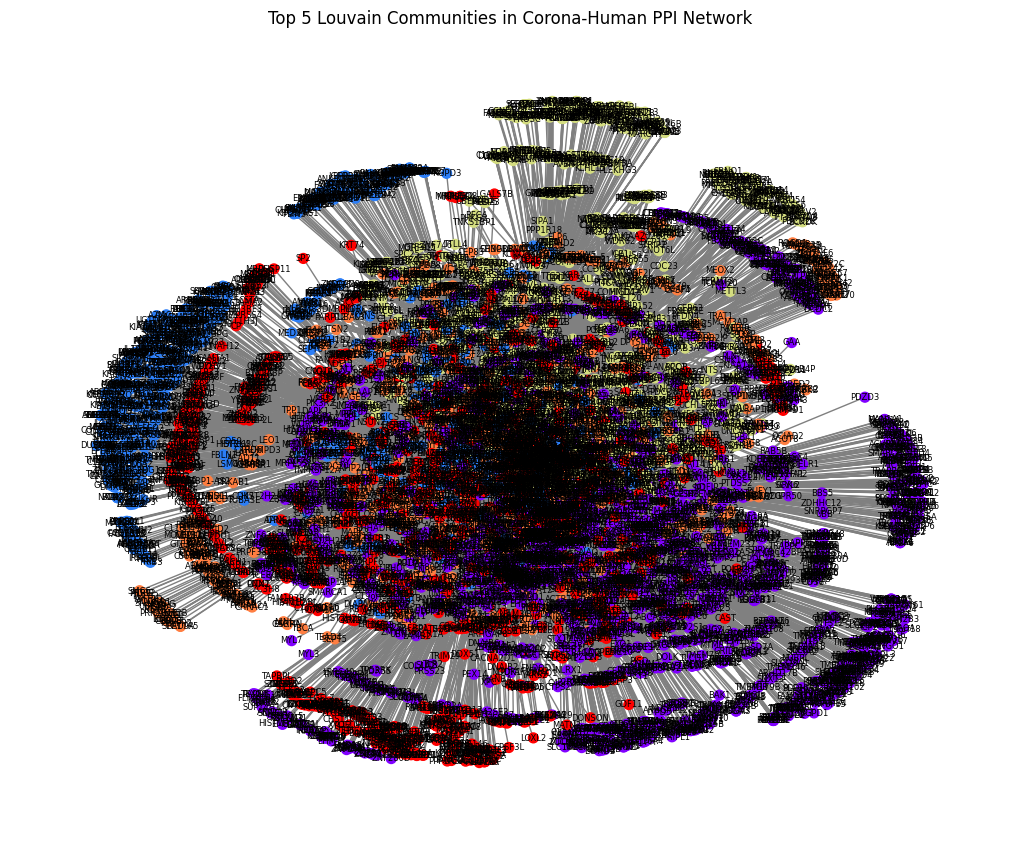

In [10]:
from collections import Counter

# Đếm số node trong mỗi cộng đồng
community_sizes = Counter(partition.values())

# Lấy top 5 cộng đồng lớn nhất
top_communities = [comm for comm, size in community_sizes.most_common(5)]

# Chỉ lấy các node thuộc top cộng đồng
filtered_nodes = [n for n in G.nodes() if partition[n] in top_communities]
filtered_G = G.subgraph(filtered_nodes)

# Vẽ lại với dữ liệu đã lọc
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(filtered_G, seed=42)
colors = [partition[n] for n in filtered_G.nodes()]
nx.draw(filtered_G, pos, node_color=colors, cmap=plt.cm.rainbow, with_labels=True, node_size=50, font_size=6, edge_color="gray")
plt.title("Top 5 Louvain Communities in Corona-Human PPI Network")
plt.show()

Vẽ biểu đồ cho top 3 cộng đồng

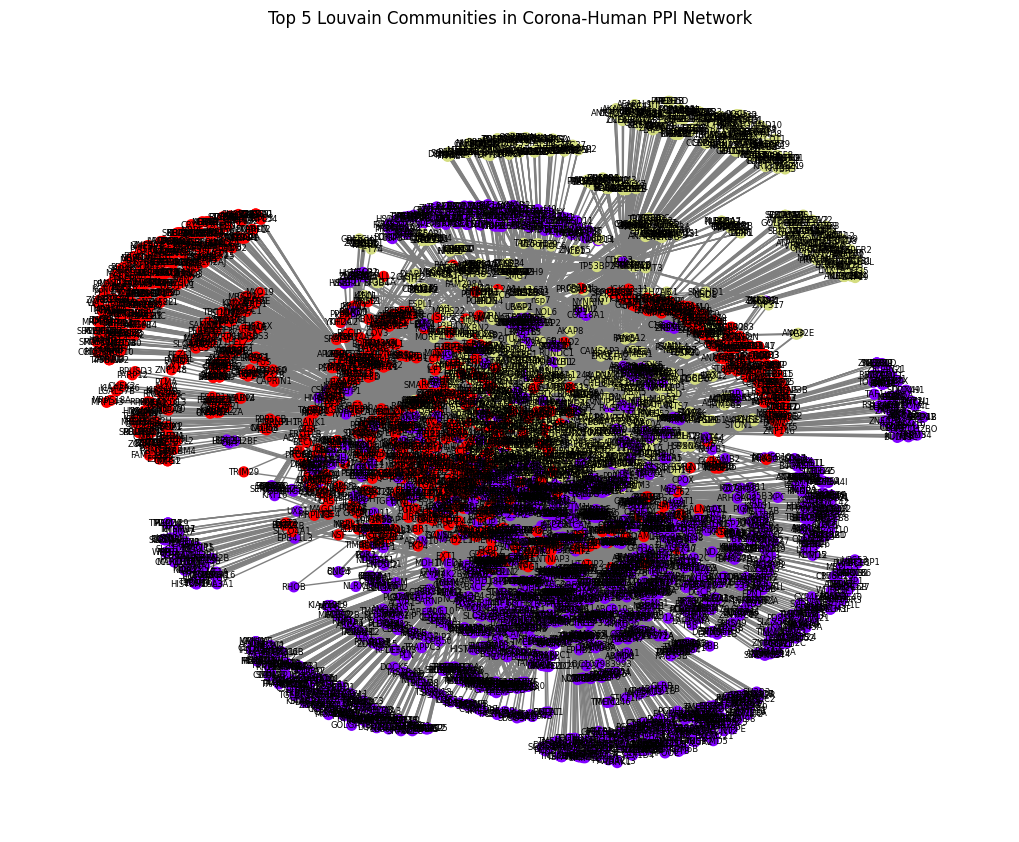

In [12]:

# Lấy top 3 cộng đồng lớn nhất
top_communities = [comm for comm, size in community_sizes.most_common(3)]

# Chỉ lấy các node thuộc top cộng đồng
filtered_nodes = [n for n in G.nodes() if partition[n] in top_communities]
filtered_G = G.subgraph(filtered_nodes)

# Vẽ lại với dữ liệu đã lọc
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(filtered_G, seed=42)
colors = [partition[n] for n in filtered_G.nodes()]
nx.draw(filtered_G, pos, node_color=colors, cmap=plt.cm.rainbow, with_labels=True, node_size=50, font_size=6, edge_color="gray")
plt.title("Top 5 Louvain Communities in Corona-Human PPI Network")
plt.show()

In [25]:
print(df["Organism Name Interactor A"].unique()) 
print(df["Organism Name Interactor B"].unique())

['Severe acute respiratory syndrome coronavirus 2' 'Homo sapiens']
['Homo sapiens' 'Severe acute respiratory syndrome coronavirus 2']


In [26]:
print(f"🔍 Số protein virus: {len(virus_proteins)}")
print(f"🔍 Số protein người: {len(human_proteins)}")


🔍 Số protein virus: 32
🔍 Số protein người: 7372


Vẽ biểu đồ cho các cộng đồng có tương tác protein giữa virus và human

Số nút (protein): 7404
Số cạnh (mối quan hệ tương tác): 30102
🔍 Tổng số cộng đồng có cả virus & người: 9
🔥 Community 7: 1778 proteins
🔥 Community 6: 926 proteins
🔥 Community 1: 907 proteins


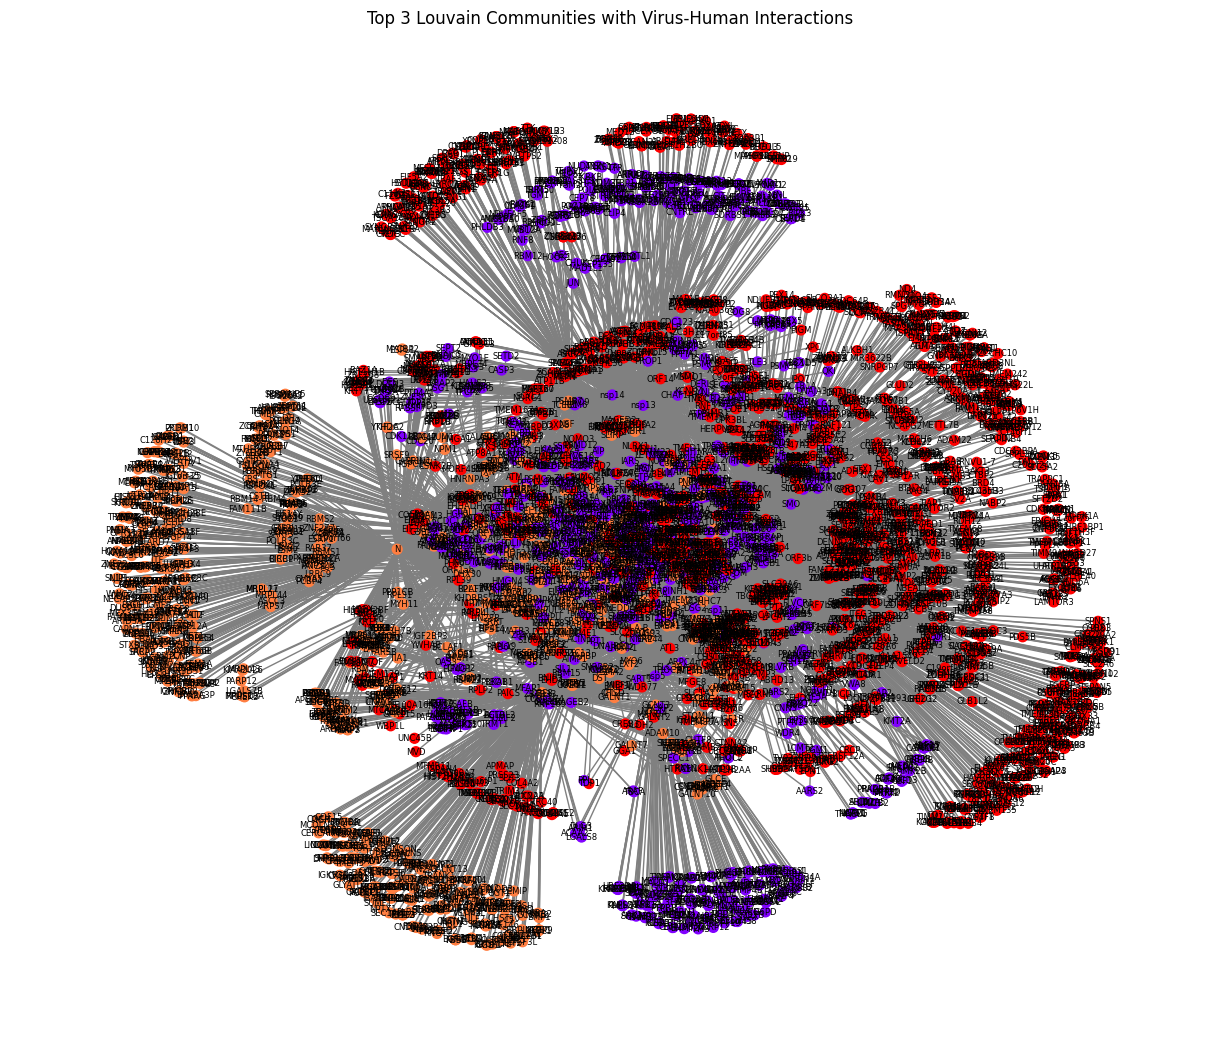

In [24]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import community  # Louvain algorithm

# 🚀 1. Tạo đồ thị
G = nx.Graph()
for _, row in df_filtered.iterrows():
    protein_A = row["Official Symbol Interactor A"]
    protein_B = row["Official Symbol Interactor B"]
    G.add_edge(protein_A, protein_B)

# 🚀 2. Thông tin về đồ thị
print(f"Số nút (protein): {G.number_of_nodes()}")
print(f"Số cạnh (mối quan hệ tương tác): {G.number_of_edges()}")

# 🚀 3. Áp dụng thuật toán Louvain để tìm cộng đồng
partition = community.best_partition(G)  # Dictionary: {node: community_id}

# 🚀 4. Lọc các cộng đồng có cả virus và người
communities = {}
for node, comm in partition.items():
    if comm not in communities:
        communities[comm] = []
    communities[comm].append(node)

# Danh sách protein virus & người
virus_proteins = set(df[df["Organism Name Interactor A"] == "Severe acute respiratory syndrome coronavirus 2"]["Official Symbol Interactor A"]) | \
                 set(df[df["Organism Name Interactor B"] == "Severe acute respiratory syndrome coronavirus 2"]["Official Symbol Interactor B"])


human_proteins = set(df[df["Organism Name Interactor A"] == "Homo sapiens"]["Official Symbol Interactor A"]) | \
                 set(df[df["Organism Name Interactor B"] == "Homo sapiens"]["Official Symbol Interactor B"])

# Chỉ giữ các cộng đồng có cả virus & người
virus_human_communities = {comm: proteins for comm, proteins in communities.items()
                           if any(p in virus_proteins for p in proteins) and any(p in human_proteins for p in proteins)}

# 🚀 5. Lấy top 3 cộng đồng lớn nhất
community_sizes = {comm: len(proteins) for comm, proteins in virus_human_communities.items()}
top_communities = [comm for comm, size in Counter(community_sizes).most_common(3)]

# In thông tin
print(f"🔍 Tổng số cộng đồng có cả virus & người: {len(virus_human_communities)}")
for comm, size in Counter(community_sizes).most_common(3):
    print(f"🔥 Community {comm}: {size} proteins")

# 🚀 6. Chỉ lấy các node thuộc top cộng đồng
filtered_nodes = [n for n in G.nodes() if partition[n] in top_communities]
filtered_G = G.subgraph(filtered_nodes)

# 🚀 7. Kiểm tra trước khi vẽ (tránh lỗi vẽ biểu đồ trống)
if filtered_G.number_of_nodes() > 0 and filtered_G.number_of_edges() > 0:
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(filtered_G, seed=42)
    colors = [partition[n] for n in filtered_G.nodes()]
    nx.draw(filtered_G, pos, node_color=colors, cmap=plt.cm.rainbow, with_labels=True, 
            node_size=50, font_size=6, edge_color="gray")
    plt.title("Top 3 Louvain Communities with Virus-Human Interactions")
    plt.show()
else:
    print("⚠️ Không có cộng đồng nào đủ lớn để vẽ đồ thị!")


In [29]:
from collections import defaultdict
from goatools import obo_parser
from goatools.associations import read_gaf
from goatools.goea.go_enrichment_ns import GOEnrichmentStudy

Danh sách các protein trong mỗi cộng đồng

In [ ]:
import pandas as pd

# 📌 Tạo danh sách dữ liệu cho từng cộng đồng
for comm, proteins in virus_human_communities.items():
    virus_list = [p for p in proteins if p in virus_proteins]
    human_list = [p for p in proteins if p in human_proteins]

    # Tạo DataFrame
    df_comm = pd.DataFrame({
        "Protein Virus": pd.Series(virus_list),
        "Protein Người": pd.Series(human_list),
        "Protein Chung": pd.Series(proteins)  # Tất cả protein trong cộng đồng
    })

    # Lưu ra file CSV
    filename = f"community_{comm}.csv"
    df_comm.to_csv(filename, index=False)
    print(f"✅ Danh sách cộng đồng {comm} đã được lưu vào '{filename}'")


✅ Danh sách cộng đồng đã được lưu vào 'communities.csv'


In [38]:
df_communities.head(5)

,Community,Protein
0,7,E
1,7,BRD4
2,7,BRD2
3,7,ZC3H18
4,7,SLC44A2


In [72]:
# 📌 Tạo danh sách dữ liệu cho từng cộng đồng
for comm, proteins in virus_human_communities.items():
    virus_list = [p for p in proteins if p in virus_proteins]
    human_list = [p for p in proteins if p in human_proteins]

    # Tạo DataFrame
    df_comm = pd.DataFrame({
        "Protein Virus": pd.Series(virus_list),
        "Protein Người": pd.Series(human_list),
        "Protein Chung": pd.Series(proteins)  # Tất cả protein trong cộng đồng
    })

    # Lưu ra file CSV
    filename = f"community_{comm}.csv"
    df_comm.to_csv(filename, index=False)
    print(f"✅ Danh sách cộng đồng {comm} đã được lưu vào '{filename}'")

✅ Danh sách cộng đồng 7 đã được lưu vào 'community_7.csv'
✅ Danh sách cộng đồng 1 đã được lưu vào 'community_1.csv'
✅ Danh sách cộng đồng 3 đã được lưu vào 'community_3.csv'
✅ Danh sách cộng đồng 8 đã được lưu vào 'community_8.csv'
✅ Danh sách cộng đồng 0 đã được lưu vào 'community_0.csv'
✅ Danh sách cộng đồng 5 đã được lưu vào 'community_5.csv'
✅ Danh sách cộng đồng 2 đã được lưu vào 'community_2.csv'
✅ Danh sách cộng đồng 4 đã được lưu vào 'community_4.csv'
✅ Danh sách cộng đồng 6 đã được lưu vào 'community_6.csv'


In [42]:
!pip install gprofiler-official



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
# Đọc file CSV (thay 'communities.csv' bằng tên file của bạn)
df_com_3= pd.read_csv("community_3.csv",encoding="utf-8", low_memory=False)

# Hiển thị vài dòng đầu tiên
df_com_3.head()

,Protein Virus,Protein Người,Protein Chung
0,nsp15,CWC27,CWC27
1,nsp9,RIPK1,RIPK1
2,NaN,UBAP2,UBAP2
3,NaN,USP54,USP54
4,NaN,NUTF2,nsp15


In [86]:

print(df_com_3.columns)  # Xem danh sách cột thực tế


Index(['Protein Virus', 'Protein Người', 'Protein Chung'], dtype='object')


In [87]:
# Gộp danh sách protein (bỏ NaN)
all_proteins =df_com_3["Protein Chung"].dropna().tolist()

print(f"Tổng số protein trong cộng đồng: {len(all_proteins)}")

Tổng số protein trong cộng đồng: 688


In [88]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
go_results = gp.profile(organism="hsapiens", query=all_proteins)

# Hiển thị 10 kết quả GO đầu tiên
go_results.head(10)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005654,nucleoplasm,2.360458e-52,True,"""That part of the nuclear content other than t...",4229,630,290,22115,0.460317,0.068574,query_1,"[GO:0031981, GO:0110165]"
1,GO:CC,GO:0031981,nuclear lumen,8.245081e-40,True,"""The volume enclosed by the nuclear inner memb...",5524,630,314,22115,0.498413,0.056843,query_1,"[GO:0005634, GO:0070013]"
2,GO:CC,GO:0043233,organelle lumen,6.347770e-36,True,"""The internal volume enclosed by the membranes...",6663,630,344,22115,0.546032,0.051628,query_1,"[GO:0031974, GO:0043226]"
3,GO:CC,GO:0070013,intracellular organelle lumen,6.347770e-36,True,"""An organelle lumen that is part of an intrace...",6663,630,344,22115,0.546032,0.051628,query_1,"[GO:0043229, GO:0043233]"
4,GO:CC,GO:0031974,membrane-enclosed lumen,6.347770e-36,True,"""The enclosed volume within a sealed membrane ...",6663,630,344,22115,0.546032,0.051628,query_1,[GO:0110165]
5,GO:CC,GO:0005829,cytosol,1.154076e-35,True,"""The part of the cytoplasm that does not conta...",5513,630,305,22115,0.484127,0.055324,query_1,"[GO:0005737, GO:0110165]"
6,GO:MF,GO:0005515,protein binding,2.054067e-34,True,"""Binding to a protein."" [GOC:go_curators]",14865,626,583,20196,0.931310,0.039220,query_1,[GO:0005488]
7,GO:CC,GO:0005634,nucleus,1.201788e-26,True,"""A membrane-bounded organelle of eukaryotic ce...",10058,630,424,22115,0.673016,0.042155,query_1,[GO:0043231]
8,GO:CC,GO:0005622,intracellular anatomical structure,3.644254e-26,True,"""A component of a cell contained within (but n...",17842,630,602,22115,0.955556,0.033741,query_1,[GO:0110165]
9,GO:CC,GO:0005694,chromosome,1.289875e-25,True,"""A structure composed of a very long molecule ...",1956,630,146,22115,0.231746,0.074642,query_1,[GO:0043232]


In [89]:
# Lọc các nhóm GO chính dựa vào cột "source" thay vì "domain"
bp_terms = go_results[go_results["source"] == "GO:BP"]  # Biological Process
mf_terms = go_results[go_results["source"] == "GO:MF"]  # Molecular Function
cc_terms = go_results[go_results["source"] == "GO:CC"]  # Cellular Component

print(f"Số lượng BP terms: {len(bp_terms)}")
print(f"Số lượng MF terms: {len(mf_terms)}")
print(f"Số lượng CC terms: {len(cc_terms)}")


Số lượng BP terms: 136
Số lượng MF terms: 32
Số lượng CC terms: 79


In [90]:
# Sắp xếp theo p-value tăng dần (p-value càng nhỏ thì càng quan trọng)
top_go_terms = go_results.sort_values(by="p_value", ascending=True)

# Lấy Top 10 thuật ngữ GO quan trọng nhất
top_go_terms.head(10)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005654,nucleoplasm,2.360458e-52,True,"""That part of the nuclear content other than t...",4229,630,290,22115,0.460317,0.068574,query_1,"[GO:0031981, GO:0110165]"
1,GO:CC,GO:0031981,nuclear lumen,8.245081e-40,True,"""The volume enclosed by the nuclear inner memb...",5524,630,314,22115,0.498413,0.056843,query_1,"[GO:0005634, GO:0070013]"
2,GO:CC,GO:0043233,organelle lumen,6.347770e-36,True,"""The internal volume enclosed by the membranes...",6663,630,344,22115,0.546032,0.051628,query_1,"[GO:0031974, GO:0043226]"
3,GO:CC,GO:0070013,intracellular organelle lumen,6.347770e-36,True,"""An organelle lumen that is part of an intrace...",6663,630,344,22115,0.546032,0.051628,query_1,"[GO:0043229, GO:0043233]"
4,GO:CC,GO:0031974,membrane-enclosed lumen,6.347770e-36,True,"""The enclosed volume within a sealed membrane ...",6663,630,344,22115,0.546032,0.051628,query_1,[GO:0110165]
5,GO:CC,GO:0005829,cytosol,1.154076e-35,True,"""The part of the cytoplasm that does not conta...",5513,630,305,22115,0.484127,0.055324,query_1,"[GO:0005737, GO:0110165]"
6,GO:MF,GO:0005515,protein binding,2.054067e-34,True,"""Binding to a protein."" [GOC:go_curators]",14865,626,583,20196,0.931310,0.039220,query_1,[GO:0005488]
7,GO:CC,GO:0005634,nucleus,1.201788e-26,True,"""A membrane-bounded organelle of eukaryotic ce...",10058,630,424,22115,0.673016,0.042155,query_1,[GO:0043231]
8,GO:CC,GO:0005622,intracellular anatomical structure,3.644254e-26,True,"""A component of a cell contained within (but n...",17842,630,602,22115,0.955556,0.033741,query_1,[GO:0110165]
9,GO:CC,GO:0005694,chromosome,1.289875e-25,True,"""A structure composed of a very long molecule ...",1956,630,146,22115,0.231746,0.074642,query_1,[GO:0043232]


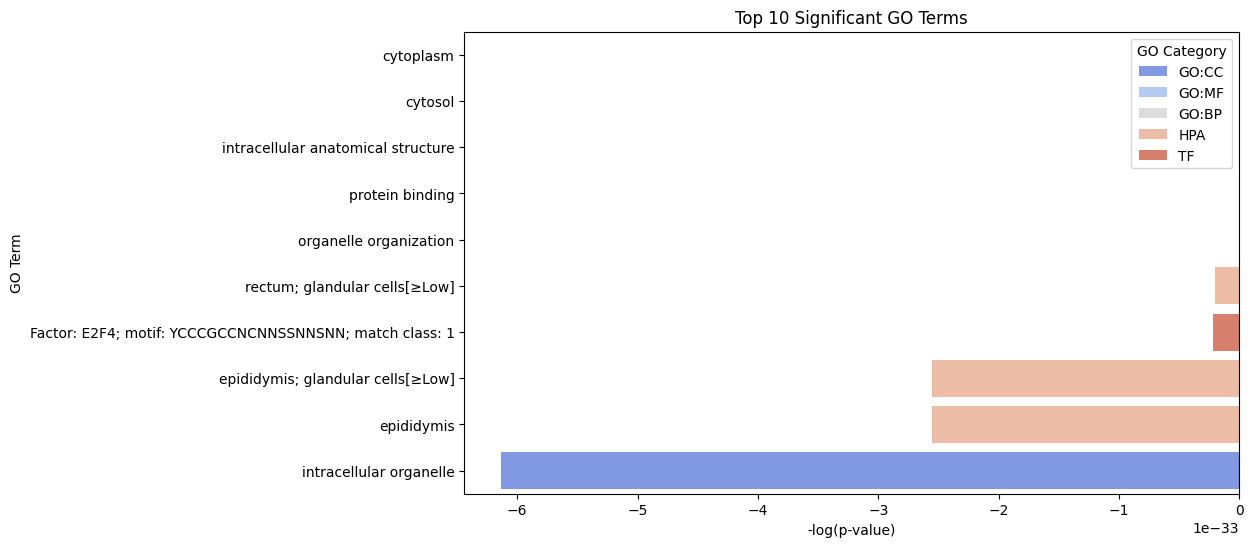

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy Top 10 GO terms có p-value thấp nhất
top_10_go = top_go_terms.head(10)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=-top_10_go["p_value"], y=top_10_go["name"], hue=top_10_go["source"], palette="coolwarm")
plt.xlabel("-log(p-value)")
plt.ylabel("GO Term")
plt.title("Top 10 Significant GO Terms")
plt.legend(title="GO Category")
plt.show()


In [92]:
from gprofiler import GProfiler

def summarize_community(df_community, community_name):
    """
    Hàm thực hiện phân tích GO cho một cộng đồng protein
    và in ra kết luận tổng quan về chức năng chính.
    
    Parameters:
    - df_community: DataFrame chứa danh sách protein trong cộng đồng.
    - community_name: Tên cộng đồng.
    """

    # Gộp danh sách protein (bỏ NaN)
    all_proteins = df_community["Protein Chung"].dropna().tolist()

    # Kiểm tra nếu danh sách protein rỗng
    if not all_proteins:
        print(f"⚠️ Không có protein nào trong {community_name}.")
        return

    print(f"🔎 Tổng số protein trong {community_name}: {len(all_proteins)}")

    # Khởi tạo GProfiler
    gp = GProfiler(return_dataframe=True)

    # Thực hiện GO Analysis
    go_results = gp.profile(organism="hsapiens", query=all_proteins)

    # Kiểm tra nếu không có kết quả GO
    if go_results.empty:
        print(f"⚠️ Không có kết quả GO terms nào cho {community_name}.")
        return

    # Lọc các nhóm GO chính
    bp_terms = go_results[go_results["source"] == "GO:BP"]  # Biological Process
    mf_terms = go_results[go_results["source"] == "GO:MF"]  # Molecular Function
    cc_terms = go_results[go_results["source"] == "GO:CC"]  # Cellular Component

    print(f"🧬 {community_name}:")
    print(f"   - {len(bp_terms)} quá trình sinh học (BP)")
    print(f"   - {len(mf_terms)} chức năng phân tử (MF)")
    print(f"   - {len(cc_terms)} thành phần tế bào (CC)")

    # Lấy các GO terms quan trọng nhất dựa trên p-value
    top_go_terms = go_results.sort_values(by="p_value", ascending=True).head(10)

    # Nhóm các đặc trưng chính
    bp_summary = top_go_terms[top_go_terms["source"] == "GO:BP"]["name"].tolist()
    mf_summary = top_go_terms[top_go_terms["source"] == "GO:MF"]["name"].tolist()
    cc_summary = top_go_terms[top_go_terms["source"] == "GO:CC"]["name"].tolist()

    # In kết luận
    print("\n📢 **Kết luận tổng quan:**")
    print(f"✔ **Chức năng sinh học chính:** {', '.join(bp_summary[:5]) if bp_summary else 'Không có'}")
    print(f"✔ **Chức năng phân tử chính:** {', '.join(mf_summary[:5]) if mf_summary else 'Không có'}")
    print(f"✔ **Thành phần tế bào chính:** {', '.join(cc_summary[:5]) if cc_summary else 'Không có'}")
    print("=" * 80, "\n")

# Ví dụ chạy cho một cộng đồng
summarize_community(df_com_3, "Cộng đồng 3")


🔎 Tổng số protein trong Cộng đồng 3: 688
🧬 Cộng đồng 3:
   - 136 quá trình sinh học (BP)
   - 32 chức năng phân tử (MF)
   - 79 thành phần tế bào (CC)

📢 **Kết luận tổng quan:**
✔ **Chức năng sinh học chính:** Không có
✔ **Chức năng phân tử chính:** protein binding
✔ **Thành phần tế bào chính:** nucleoplasm, nuclear lumen, organelle lumen, intracellular organelle lumen, membrane-enclosed lumen

